# 02 - Chunking Lab

Five chunking strategies, two evaluation layers, one question: does
structure-aware chunking beat a plain character splitter on financial filings?

Logic lives in `src/chunking/*` and `src/eval/*`. The long-running sweeps have
script equivalents: `scripts/build_chunking_strategies.py`,
`scripts/run_retrieval_eval.py`, `scripts/run_generation_eval.py`.


In [3]:
# notebooks are thin: every function called here lives in src/
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.chunking import build_all
from src.chunking.naive_fixed import naive_fixed_size_chunks
from src.chunking.row_group import build_row_group_chunks
from src.chunking.row_level import build_row_level_chunks
from src.chunking.sentence_window import build_sentence_window_chunks
from src.chunking.whole_table import build_whole_table_chunks
from src.utils.io import load_jsonl, save_jsonl

documents = load_jsonl("data/processed/documents.jsonl")
eval_examples = load_jsonl("data/processed/eval_dataset.jsonl")
print(f"{len(documents)} documents, {len(eval_examples)} questions")


299 documents, 883 questions


## 1. Build the chunk stores

| # | strategy | idea |
|---|----------|------|
| 1 | row-level | one chunk per table row / text line (gold-aligned baseline) |
| 2 | naive fixed-size | 500-char windows over flat text, structure-blind control |
| 3 | whole-table | the entire table as one chunk, text unchanged from 1 |
| 4 | sentence-window | text line embedded with its neighbours, table rows unchanged from 1 |
| 5 | row-group-5 | group 5 table rows per chunk — sits between 1 and 3 on the precision/context dial |
| 6 | parent-child | retrieve on row-level children, return whole parent table as context |


In [4]:
strategies = {
    "row_level":       (build_row_level_chunks,                          "data/processed/chunks.jsonl"),
    "naive_fixed":     (naive_fixed_size_chunks,                         "data/processed/chunks_naive_fixed.jsonl"),
    "whole_table":     (build_whole_table_chunks,                        "data/processed/chunks_whole_table.jsonl"),
    "sentence_window": (build_sentence_window_chunks,                    "data/processed/chunks_sentence_window.jsonl"),
    "row_group_5":     (lambda doc: build_row_group_chunks(doc, 5),      "data/processed/chunks_grouped_5.jsonl"),
}

for name, (builder, out_path) in strategies.items():
    chunks = build_all(documents, builder)
    save_jsonl(chunks, out_path)
    print(f"{name:<16} {len(chunks):>6} chunks -> {out_path}")


row_level          8931 chunks -> data/processed/chunks.jsonl
naive_fixed        2689 chunks -> data/processed/chunks_naive_fixed.jsonl
whole_table        7575 chunks -> data/processed/chunks_whole_table.jsonl
sentence_window    8931 chunks -> data/processed/chunks_sentence_window.jsonl
row_group_5        7718 chunks -> data/processed/chunks_grouped_5.jsonl


In [5]:
# what the granularity difference actually looks like
whole_table = build_all(documents[:1], build_whole_table_chunks)
row_level = build_all(documents[:1], build_row_level_chunks)

print("row-level table chunk:")
print(" ", next(c["text"] for c in row_level if c["chunk_type"] == "table_row")[:220])
print("\nwhole-table chunk:")
print(" ", next(c["text"] for c in whole_table if c["chunk_type"] == "whole_table")[:220].replace("\n", "\n  "))


row-level table chunk:
  Visa Inc.(1): Payments Volume (billions) is $2,457; Total Volume (billions) is $3,822; Total Transactions (billions) is 50.3; Cards (millions) is 1,592.

whole-table chunk:
  Company | Payments Volume (billions) | Total Volume (billions) | Total Transactions (billions) | Cards (millions)
  Visa Inc.(1) | $2,457 | $3,822 | 50.3 | 1,592
  MasterCard | 1,697 | 2,276 | 27.0 | 916
  American Express | 6


## 2. Retrieval eval

Two scorers, and picking the wrong one invalidates the comparison:

- `evaluate_chunking_strategy` matches gold ids exactly. Only valid for the
  row-level id scheme - a `whole_table` chunk can never equal a `table_row` id.
- `evaluate_chunking_strategy_generic` matches on content overlap, so it works
  across granularities. This is the one used for cross-strategy numbers.

Noise-flagged chunks are excluded from every index via `load_index_chunks`.


In [6]:
from src.eval.retrieval_harness import (
    evaluate_chunking_strategy,
    evaluate_chunking_strategy_generic,
    gold_text_index,
    load_embedder,
    load_index_chunks,
)
from src.utils.io import save_json

model = load_embedder()
chunk_id_to_gold_text = gold_text_index(load_jsonl("data/processed/chunks.jsonl"))

result_paths = {
    "row_level":       "data/processed/eval_results_baseline_row_level.json",
    "naive_fixed":     "data/processed/eval_results_naive_fixed.json",
    "whole_table":     "data/processed/eval_results_whole_table.json",
    "sentence_window": "data/processed/eval_results_sentence_window.json",
    "row_group_5":     "data/processed/eval_results_row_group_5.json",
}

for name, (_, chunks_path) in strategies.items():
    chunks = load_index_chunks(chunks_path)
    print(f"\nevaluating {name}: {len(chunks)} chunks...")
    summary = evaluate_chunking_strategy_generic(chunks, eval_examples, chunk_id_to_gold_text, model)
    for k, s in summary.items():
        print(f"  k={k:>2}  precision={s['precision']:.3f}  recall={s['recall']:.3f}")
    save_json(summary, result_paths[name])


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


evaluating row_level: 8532 chunks...


Batches:   0%|          | 0/134 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

  k= 1  precision=0.440  recall=0.440
  k= 3  precision=0.301  recall=0.564
  k= 5  precision=0.238  recall=0.628
  k=10  precision=0.161  recall=0.702

evaluating naive_fixed: 2689 chunks...


...

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

  k= 1  precision=0.480  recall=0.480
  k= 3  precision=0.401  recall=0.600
  k= 5  precision=0.329  recall=0.654
  k=10  precision=0.237  recall=0.722

evaluating row_group_5: 7319 chunks...


Batches:   0%|          | 0/115 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

  k= 1  precision=0.472  recall=0.472
  k= 3  precision=0.303  recall=0.630
  k= 5  precision=0.231  recall=0.713
  k=10  precision=0.148  recall=0.790


In [7]:
# exact-id scoring, shown only for the baseline where it is meaningful
exact = evaluate_chunking_strategy(load_index_chunks("data/processed/chunks.jsonl"),
                                    eval_examples, model)
for k, s in exact.items():
    print(f"k={k:>2}  precision={s['precision']:.3f}  recall={s['recall']:.3f}")


Batches:   0%|          | 0/134 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

k= 1  precision=0.323  recall=0.282
k= 3  precision=0.177  recall=0.421
k= 5  precision=0.123  recall=0.474
k=10  precision=0.075  recall=0.557


## 3. Generation eval

Retrieval metrics only say whether the evidence was fetched. What settles the
argument is whether the LLM could then compute the answer, so each strategy is
run through a local Ollama model on a fixed, operation-stratified 44-question
sample. Ground truth is `exe_ans`, not the noisy human-typed `answer` field.

Roughly 4 x 44 sequential LLM calls, so this cell takes 15-20 minutes.


In [8]:
from src.eval.generation_harness import LLM_MODEL, run_generation_eval
from src.eval.sampling import stratified_sample_by_op

sample = stratified_sample_by_op(eval_examples, per_op_n=5)
save_jsonl(sample, "data/processed/gen_eval_sample.jsonl")
print(f"{len(sample)} questions, LLM={LLM_MODEL}")

# strategies 1-5 (row_group_5 is new here; uses same sample so results are directly comparable)
all_results = {}
for name, (_, chunks_path) in strategies.items():
    print(f"\n=== {name} ===")
    result = run_generation_eval(load_index_chunks(chunks_path), sample, model, top_k=5)
    print(f"{name} accuracy: {result['accuracy']:.1%}")
    all_results[name] = result

save_json({k: v["accuracy"] for k, v in all_results.items()},
          "data/processed/generation_comparison.json")
save_json(all_results, "data/processed/eval_results_generation.json")


44 questions, LLM=qwen2.5:7b-instruct

=== row_level ===


Batches:   0%|          | 0/134 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✗  exe_ans=0.84882      generated='72.5%'
✓  exe_ans=0.14336      generated='14.4%'
✓  exe_ans=0.0837       generated='8.4%'
✗  exe_ans=0.79233      generated='no'
✗  exe_ans=0.28448      generated='-25.7%'
✗  exe_ans=-0.2108      generated='No'
✓  exe_ans=-0.42327     generated='42.3%'
✗  exe_ans=0.01408      generated='-4.0%'
✓  exe_ans=-147.0       generated='-147'
✓  exe_ans=0.16735      generated='16.98%'
✓  exe_ans=0.36029      generated='35.9%'
✗  exe_ans=-1.6         generated='-195'
✗  exe_ans=1041.531     generated='No'
✗  exe_ans=778000.0     generated='0'
✓  exe_ans=16.5         generated='16.5%'
✗  exe_ans=0.015        generated='75%'
✗  exe_ans=0.78247      generated='88%'
✗  exe_ans=8632.0       generated='First, calculate the fair value at the e'
✗  exe_ans=0.54126      generated='19.9%'
✗  exe_ans=0.06354      generated='N/A'
✗  exe_ans=6140.0       generated='No'
✗  exe_ans=5.2          generated='3.6'
✓  exe_ans=1891.16667   generated='1891.17'
✓  exe_ans=2758.55    

Batches:   0%|          | 0/43 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 4. Comparison

Note the disagreement between the two layers: row-level wins on retrieval
precision but whole-table wins on answer accuracy. Most FinQA questions need two
cells from the same table, and a whole-table chunk hands the model both at once.


Strategy                       P@5      R@5     P@10     R@10   gen acc
Row-level (baseline)         0.238    0.628    0.161    0.702    40.9%
Naive fixed-size             0.237    0.765    0.153    0.815    29.5%
Whole-table                  0.205    0.709    0.129    0.798    45.5%
Sentence-window              0.329    0.654    0.237    0.722    36.4%


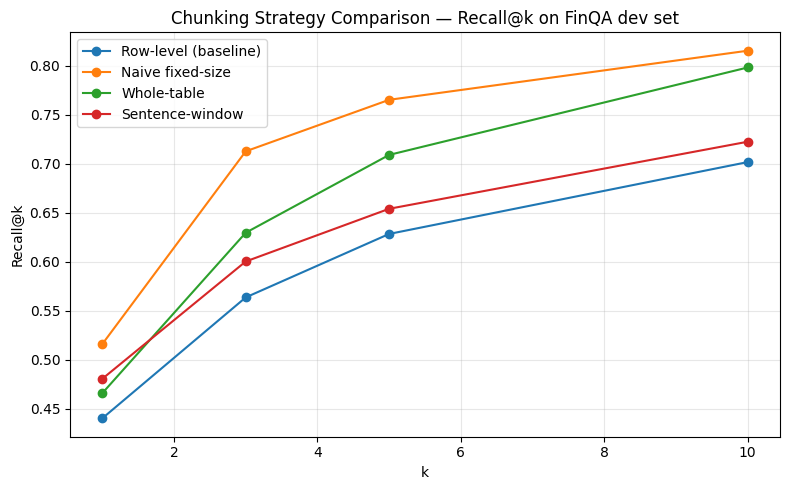


chart written to /Users/saivardhannarla/projects/Mulit-Document Ingestions/data/processed/chunking_comparison.png


In [9]:
from scripts.build_comparison_report import build_report

retrieval, generation = build_report(show=True)


## 5. Strategy 6: parent-child (small-to-big)

**How it works:**
- *Index:* row-level chunks — same ids as strategy 1, so gold-id matching and
  `retrieval_hit_rate` are directly comparable.
- *Context to the LLM:* after retrieval, each top-k row is expanded to its whole
  parent table (or sentence-window for text lines). Multiple rows from the same
  table deduplicates to one table entry in the prompt.

`src/chunking/parent_child.py` contains `build_index_chunks` and `build_parent_text_map`.
`src/eval/generation_harness.py` contains `run_parent_child_eval`.


In [ ]:
from src.chunking.parent_child import build_index_chunks, build_parent_text_map

# retrieval index = row-level (byte-identical to strategy 1)
pc_index_chunks = build_index_chunks(documents)
save_jsonl(pc_index_chunks, "data/processed/chunks_parent_child_index.jsonl")
print(f"parent-child index:  {len(pc_index_chunks)} chunks  (= row-level count)")

# child_id -> whole-table text (or sentence-window for text lines), built once
parent_text_map = build_parent_text_map(documents)
print(f"parent map entries:  {len(parent_text_map)}")

# spot-check
first_gold = eval_examples[0]["gold_chunk_ids"][0]
print(f"\ngold child id:       {first_gold}")
print(f"parent context (300 chars):")
print(parent_text_map.get(first_gold, "NOT FOUND")[:300])


### 5b. Parent-child generation eval

Same 44-question sample as strategies 1-5 → numbers are directly comparable.
Retrieval hit rate is also comparable here (same row-level ids as strategy 1).

Cell takes ~5 minutes (44 × 1 LLM call).


In [ ]:
from src.eval.generation_harness import run_parent_child_eval
from src.utils.io import load_jsonl, save_json

# load the fixed 44-question sample written by the generation eval cell above
sample = load_jsonl("data/processed/gen_eval_sample.jsonl")
print(f"evaluating parent-child on {len(sample)} questions via {LLM_MODEL}")

pc_chunks = [c for c in pc_index_chunks if not c.get("is_noise", False)]
pc_result = run_parent_child_eval(pc_chunks, parent_text_map, sample, model, top_k=5)

print(f"\nparent-child accuracy : {pc_result['accuracy']:.1%}  "
      f"({sum(r['correct'] for r in pc_result['results'])}/{pc_result['n']})")
print(f"retrieval hit-rate    : {pc_result['retrieval_hit_rate']:.1%}")

save_json(pc_result, "data/processed/eval_results_parent_child.json")
all_results["parent_child"] = pc_result


## 6. Head-to-head generation comparison

All six strategies, same 44 questions, same LLM. The table below is printed in
accuracy order so you can see at a glance whether parent-child or row-group-5
beats whole-table.


In [ ]:
# merge any on-disk generation results we may not have re-run in this session
import json as _json
from pathlib import Path as _Path

_gen_paths = {
    "row_level":       "data/processed/eval_results_generation.json",
    "naive_fixed":     "data/processed/eval_results_generation.json",
    "whole_table":     "data/processed/eval_results_generation.json",
    "sentence_window": "data/processed/eval_results_generation.json",
    "row_group_5":     "data/processed/eval_results_generation.json",
    "parent_child":    "data/processed/eval_results_parent_child.json",
}

def _acc(name):
    # all_results is in-memory when cells were run top-to-bottom
    if name in all_results:
        return all_results[name]["accuracy"]
    # fallback: read from the saved JSON
    p = _Path(ROOT) / "data/processed/eval_results_generation.json"
    if p.exists():
        d = _json.loads(p.read_text())
        if name in d:
            r = d[name]
            return r["accuracy"] if isinstance(r, dict) else r
    p2 = _Path(ROOT) / f"data/processed/eval_results_{name}.json"
    if p2.exists():
        d = _json.loads(p2.read_text())
        return d.get("accuracy", float("nan"))
    return float("nan")

rows = [
    ("row_level",       "row-level (strategy 1)"),
    ("naive_fixed",     "naive fixed-size (strategy 2)"),
    ("whole_table",     "whole-table (strategy 3)"),
    ("sentence_window", "sentence-window (strategy 4)"),
    ("row_group_5",     "row-group-5 (strategy 5)"),
    ("parent_child",    "parent-child (strategy 6)"),
]
rows.sort(key=lambda r: -_acc(r[0]))

print(f"{'strategy':<30}  {'accuracy':>8}")
print("-" * 42)
for key, label in rows:
    acc = _acc(key)
    bar = "█" * round(acc * 20)
    print(f"{label:<30}  {acc:>7.1%}  {bar}")


## 7. Table chunk-size sweep (retrieval only, no LLM)

How many rows per group gives the best retrieval recall?
`scripts/run_chunk_size_sweep.py` handles this; the cell below is a thin wrapper.
Takes ~2 minutes (embedding only, no Ollama needed).


In [ ]:
import importlib.util as _ilu
from pathlib import Path as _P

_spec = _ilu.spec_from_file_location(
    "run_chunk_size_sweep",
    _P(ROOT) / "scripts" / "run_chunk_size_sweep.py",
)
_mod = _ilu.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
run_sweep = _mod.run_sweep

sweep = run_sweep(sizes=[1, 2, 3, 5, 999], top_k=5, model=model)


## 8. Known caveats

- `retrieval_hit_rate` inside generation eval uses exact chunk_id matching.
  It is only comparable across strategies that share the same id scheme.
  Parent-child (strategy 6) uses row-level ids, so its number IS comparable to strategy 1.
  Whole-table (strategy 3) uses different ids, so its hit_rate is *not* comparable.
- 65 of 883 questions carry no gold annotations in FinQA; they are excluded from
  recall denominators but are included in generation accuracy (the LLM still tries).
- All generation numbers come from the same fixed 44-question sample.
  Narrow margins (<3 pp) should be treated as suggestive, not settled.
